# Cifrium Retention Intelligence

## Early churn prediction on Day 14 of learning

**North Star:** Course Completion Rate  
**Decision metric:** Module 1 → Module 2 transition  
**Model output:** D14 Churn Risk Score

This notebook follows the product decision from retention diagnosis to a capacity-aware ML model.


## 1. Key data decision: learning start ≠ enrollment date

The administrative enrollment date precedes the actual learning start by a median of roughly **26 days**.

Therefore the D14 observation window is anchored to the first scheduled lesson of the student's parallel:

`stats.id параллели → groups.group_template_id → min(groups.starts_at)`


In [1]:
from pathlib import Path
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
from catboost import CatBoostClassifier

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.append(str(ROOT))

from src.features import build_student_base, build_d14_media_features
from src.evaluation import evaluate_scores

DATA = Path(os.getenv("CIFRIUM_DATA_DIR", ROOT / "data"))


In [2]:
stats = pd.read_csv(DATA / "stats__module_1.csv")
groups = pd.read_csv(DATA / "groups.csv")
media = pd.read_csv(DATA / "wk_media_view_sessions.csv")

base = build_student_base(stats, groups)
df = build_d14_media_features(base, media)

print(f"Students with valid learning start: {len(df):,}")
print(f"Churn rate: {df['churn'].mean():.1%}")
print(f"Learning starts: {df['learning_start'].min()} → {df['learning_start'].max()}")


Students with valid learning start: 2,972
Churn rate: 34.2%
Learning starts: 2025-10-14 07:00:00 → 2025-11-17 16:00:00


## 2. Behavioral product analytics

The goal is to find signals that are both predictive and interpretable as retention diagnostics.


In [3]:
behavior_cols = [
    "media_sessions_d14",
    "media_active_days_d14",
    "media_unique_resources_d14",
    "media_avg_watch_pct_d14",
    "media_watch80_rate_d14",
    "media_recency_days_d14",
    "media_max_inactivity_gap_d14",
    "media_sessions_w2",
    "media_sessions_last3d",
]

behavior_summary = df.groupby("churn")[behavior_cols].mean().T
behavior_summary.columns = ["retained", "churn"]
behavior_summary


,retained,churn
media_sessions_d14,9.578517,1.694199
media_active_days_d14,2.819949,0.595870
media_unique_resources_d14,6.834271,1.137660
media_avg_watch_pct_d14,0.467867,0.102975
media_watch80_rate_d14,0.322299,0.051757
media_recency_days_d14,4.430577,11.221504
media_max_inactivity_gap_d14,8.013811,12.422812
media_sessions_w2,5.936573,0.800393
media_sessions_last3d,3.322251,0.429695


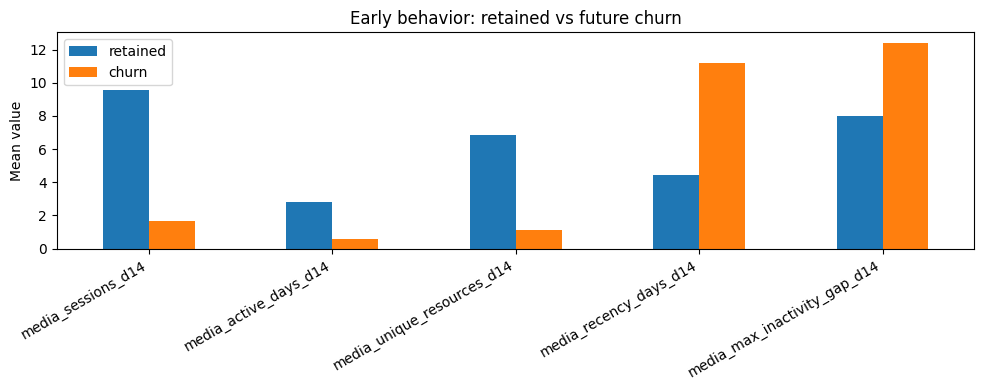

In [4]:
plot_df = behavior_summary.loc[
    ["media_sessions_d14","media_active_days_d14","media_unique_resources_d14",
     "media_recency_days_d14","media_max_inactivity_gap_d14"]
].copy()

plot_df.plot(kind="bar", figsize=(10,4))
plt.title("Early behavior: retained vs future churn")
plt.ylabel("Mean value")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


The dominant pattern is loss of cadence: future churners have fewer active days, fewer resources, weaker continuation into week 2, and much longer recency by D14.


## 3. Chronological validation

Headline metrics use future cohorts, not a random split.


In [5]:
date_counts = df.groupby("learning_start").size().sort_index()
cumulative = date_counts.cumsum() / date_counts.sum()
split_date = cumulative[cumulative <= 0.80].index[-1]

train = df[df["learning_start"] <= split_date].copy()
test = df[df["learning_start"] > split_date].copy()

print("Train:", len(train), f"churn={train.churn.mean():.1%}")
print("Test: ", len(test), f"churn={test.churn.mean():.1%}")
print("Split:", split_date)


Train: 2357 churn=35.2%
Test:  615 churn=30.6%
Split: 2025-11-12 07:00:00


In [6]:
meta = [
    "enrollment_lead_days", "cohort_size_at_start",
    "start_weekday", "start_hour", "Уровень", "course_id"
]
media_features = [c for c in df.columns if c.startswith("media_")]
features = meta + media_features
categorical = ["start_weekday", "Уровень", "course_id"]
numeric = [c for c in features if c not in categorical]

X_train, y_train = train[features].copy(), train["churn"]
X_test, y_test = test[features].copy(), test["churn"]


## 4. Model comparison


In [7]:
def topk(y, p, share=0.20):
    y = np.asarray(y)
    p = np.asarray(p)
    n = max(1, int(np.ceil(len(y) * share)))
    idx = np.argsort(-p)[:n]
    precision = y[idx].mean()
    recall = y[idx].sum() / y.sum()
    lift = precision / y.mean()
    return precision, recall, lift

# Logistic Regression
prep = ColumnTransformer([
    ("num", Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]), numeric),
    ("cat", Pipeline([
        ("imp", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore")),
    ]), categorical),
])

logit = Pipeline([
    ("prep", prep),
    ("model", LogisticRegression(max_iter=3000, class_weight="balanced", random_state=42))
])
logit.fit(X_train, y_train)
p_logit = logit.predict_proba(X_test)[:,1]

# Random Forest
rf_features = [c for c in features if c not in categorical]
rf = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=500, max_depth=8, min_samples_leaf=8,
        class_weight="balanced", random_state=42, n_jobs=-1
    ))
])
rf.fit(X_train[rf_features], y_train)
p_rf = rf.predict_proba(X_test[rf_features])[:,1]


In [8]:
# CatBoost: validation tail inside the historical training period
Xcb_train, Xcb_test = X_train.copy(), X_test.copy()
for c in categorical:
    Xcb_train[c] = Xcb_train[c].astype(str).fillna("missing")
    Xcb_test[c] = Xcb_test[c].astype(str).fillna("missing")
for c in numeric:
    Xcb_train[c] = pd.to_numeric(Xcb_train[c], errors="coerce").fillna(0)
    Xcb_test[c] = pd.to_numeric(Xcb_test[c], errors="coerce").fillna(0)

train_dates = train.groupby("learning_start").size().sort_index()
train_cum = train_dates.cumsum() / train_dates.sum()
val_date = train_cum[train_cum <= 0.80].index[-1]
fit_mask = train["learning_start"] <= val_date
val_mask = train["learning_start"] > val_date

cat_idx = [features.index(c) for c in categorical]

cat = CatBoostClassifier(
    iterations=1200,
    depth=4,
    learning_rate=0.04,
    l2_leaf_reg=5,
    loss_function="Logloss",
    eval_metric="AUC",
    auto_class_weights="Balanced",
    random_seed=42,
    verbose=False,
)

cat.fit(
    Xcb_train.loc[fit_mask], y_train.loc[fit_mask],
    cat_features=cat_idx,
    eval_set=(Xcb_train.loc[val_mask], y_train.loc[val_mask]),
    early_stopping_rounds=100,
    verbose=False,
)

p_cat = cat.predict_proba(Xcb_test)[:,1]


In [9]:
rows = []
for name, p in [
    ("Logistic Regression", p_logit),
    ("Random Forest", p_rf),
    ("CatBoost", p_cat),
]:
    precision, recall, lift = topk(y_test, p, .20)
    rows.append({
        "model": name,
        "ROC-AUC": roc_auc_score(y_test, p),
        "PR-AUC": average_precision_score(y_test, p),
        "Brier": brier_score_loss(y_test, p),
        "Precision@20%": precision,
        "Recall@20%": recall,
        "Lift@20%": lift,
    })

results = pd.DataFrame(rows).sort_values("PR-AUC", ascending=False)
results


,model,ROC-AUC,PR-AUC,Brier,Precision@20%,Recall@20%,Lift@20%
0,Logistic Regression,0.911026,0.800153,0.117636,0.804878,0.526596,2.632979
1,Random Forest,0.906417,0.796726,0.122466,0.821138,0.537234,2.686170
2,CatBoost,0.898126,0.778269,0.149337,0.813008,0.531915,2.659574


## 5. Product interpretation

The future-cohort holdout shows:

- **Logistic Regression:** best overall ROC-AUC (0.911), PR-AUC (0.800) and Brier score (0.118).
- **Random Forest:** best operational Top-20% ranking — Precision 82.1%, Recall 53.7%, Lift 2.69×.
- **CatBoost:** competitive, but it does not beat the simpler models on this feature set.

Because curator capacity is the explicit product constraint, **Random Forest is selected as the operating model**.

At 20% curator capacity, more than half of future churners are captured in the priority queue.


In [10]:
capacity_rows = []
for share in [0.10, 0.20, 0.30]:
    precision, recall, lift = topk(y_test, p_cat, share)
    capacity_rows.append({
        "capacity": share,
        "precision": precision,
        "recall": recall,
        "lift": lift,
    })
pd.DataFrame(capacity_rows)


,capacity,precision,recall,lift
0,0.1,0.903226,0.297872,2.954701
1,0.2,0.813008,0.531915,2.659574
2,0.3,0.697297,0.686170,2.281052


## 6. Feature importance

Model importance is predictive, not causal. For intervention design, cadence signals such as recency, week-2 continuation and inactivity gaps are more directly actionable than schedule metadata.


In [11]:
importance = pd.DataFrame({
    "feature": features,
    "importance": cat.get_feature_importance(),
}).sort_values("importance", ascending=False)

importance.head(15)


,feature,importance
3,start_hour,15.052189
8,media_unique_resources_d14,12.624124
0,enrollment_lead_days,10.040221
21,media_median_inter_session_h_d14,9.958106
10,media_median_watch_pct_d14,6.671580
27,media_unique_resources_w2,4.843709
1,cohort_size_at_start,4.139735
12,media_watch50_rate_d14,3.803896
29,media_avg_watch_w2,3.773253
17,media_max_inactivity_gap_d14,3.698931


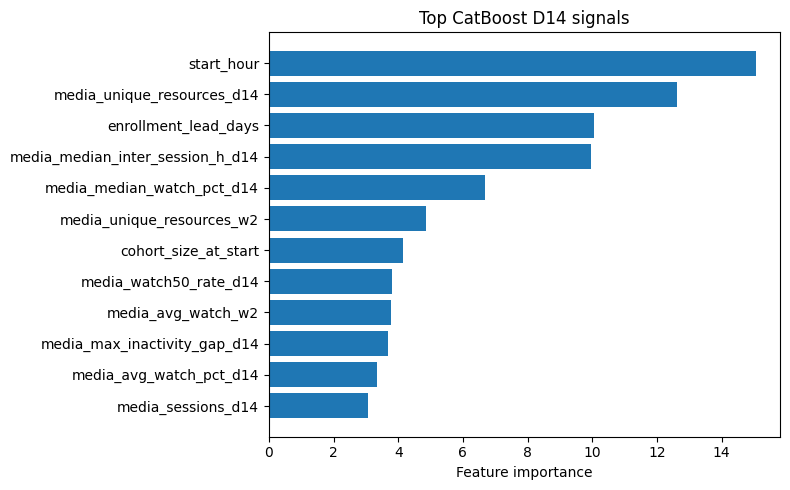

In [12]:
top = importance.head(12).sort_values("importance")
plt.figure(figsize=(8,5))
plt.barh(top["feature"], top["importance"])
plt.title("Top CatBoost D14 signals")
plt.xlabel("Feature importance")
plt.tight_layout()
plt.show()


# 7. Product activation

The model should create a ranked intervention queue:

- **High risk:** personal curator outreach.
- **Medium risk:** automated reactivation / study-plan nudge.
- **Low risk:** standard journey.

The exact threshold follows curator capacity.


# 8. Experiment design

Prediction is not causal impact.

Among high-risk D14 students:

- **Control:** business-as-usual.
- **Treatment:** standardized curator outreach.
- **Primary metric:** M1 → M2 Transition Rate.
- **Secondary metric:** Course Completion Rate.
- **Guardrails:** curator workload, intervention cost, complaints / opt-outs.

Only the experiment can estimate incremental retention uplift.
